# Classificação de Gênero de Livros com Machine Learning

Este notebook tem como objetivo desenvolver um modelo de Machine Learning capaz de classificar o gênero de livros com base em seus títulos.

Foi utilizado um dataset da plataforma Goodreads contendo milhares de livros e seus respectivos gêneros.

Serão aplicados algoritmos clássicos de Machine Learning com a biblioteca Scikit-Learn.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

## Carregamento dos Dados

In [ ]:
url = "https://raw.githubusercontent.com/stephaniefay/s4-mvp/refs/heads/main/backend/Machine%20Learning/dataset/data.csv"
dataset = pd.read_csv(url)

dataset.head()

,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve..."


## Análise Inicial

Nesta etapa, analisamos a estrutura da base de dados e verificamos possíveis valores ausentes.

In [22]:
dataset.info()
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Book Id             11127 non-null  int64  
 1   Title               11127 non-null  object 
 2   Author              11127 non-null  object 
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  object 
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  object 
 7   num_pages           11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  object 
 11  publisher           11127 non-null  object 
 12  genres              11030 non-null  object 
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


,0
Book Id,0
Title,0
Author,0
average_rating,0
isbn,0
isbn13,0
language_code,0
num_pages,0
ratings_count,0
text_reviews_count,0


## Pré-processamento

Como o dataset possui múltiplos gêneros por livro, foi feita a separação dos gêneros para melhor treinar o modelo.

Além disso, como não há sinopse, foi utilizado apenas o título como entrada textual.

In [23]:
# Remover valores nulos
dataset = dataset.dropna(subset=['Title', 'genres'])

# Manter apenas o primeiro gênero
dataset['genres'] = dataset['genres'].apply(lambda x: x.split(',')[0].strip().lower())

# Contar a frequência de cada gênero
genre_counts = dataset['genres'].value_counts()

# Identificar gêneros com apenas 1 ocorrência
single_occurrence_genres = genre_counts[genre_counts == 1].index

# Remover linhas com gêneros de apenas 1 ocorrência
dataset = dataset[~dataset['genres'].isin(single_occurrence_genres)]

# Criar coluna de texto (somente título)
dataset['text'] = dataset['Title']

X = dataset['text']
y = dataset['genres']

## Separação dos Dados

Os dados foram divididos em:
- 80% treino
- 20% teste

Foi utilizada estratificação para manter a proporção das classes.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=7
)

## Validação Cruzada

Será utilizada validação cruzada estratificada com 10 partições.

In [25]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

## Modelos Utilizados

Serão avaliados os seguintes algoritmos:
- KNN
- Árvore de Decisão
- Naive Bayes
- SVM

Foi utilizada a técnica de Pipeline para integrar o TF-IDF com os modelos.

In [26]:
models = [
    ("KNN", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", KNeighborsClassifier())
    ])),

    ("Decision Tree", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", DecisionTreeClassifier(random_state=7))
    ])),

    ("Naive Bayes", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", MultinomialNB())
    ])),

    ("SVM", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", SVC(kernel='linear'))
    ])),
]

## Avaliação dos Modelos

Os modelos serão avaliados utilizando validação cruzada com a métrica de acurácia.

In [27]:
results = []
names = []

for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")

    results.append(scores)
    names.append(name)

    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


KNN: 0.1874 (+/- 0.0386)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Decision Tree: 0.3078 (+/- 0.0145)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Naive Bayes: 0.0967 (+/- 0.0047)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


SVM: 0.3013 (+/- 0.0075)


## Comparação dos Modelos

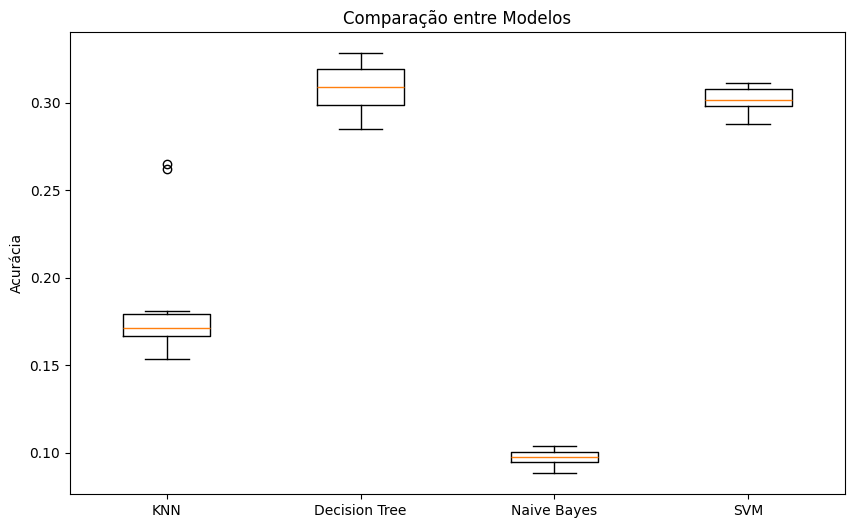

In [28]:
plt.figure(figsize=(10,6))
plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names)
plt.title("Comparação entre Modelos")
plt.ylabel("Acurácia")
plt.show()

## Otimização de Hiperparâmetros

Será utilizado GridSearch para encontrar os melhores parâmetros para o modelo SVM.

In [29]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC())
])

param_grid = {
    'tfidf__max_features': [1000, 2000],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']
}

grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Best parameters: {'svm__C': 10, 'svm__kernel': 'linear', 'tfidf__max_features': 2000}


## Avaliação Final no Conjunto de Teste

In [30]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.33209417596034696

Classification Report:
                                                                                                                      precision    recall  f1-score   support

                                                                                                           academic       0.00      0.00      0.00         1
                                                                                                      adult fiction       0.40      0.67      0.50         3
                                                                                                          adventure       0.00      0.00      0.00         1
                                                        adventure;fiction;thriller;action;mystery;suspense;thriller       0.00      0.00      0.00         1
                                                                                                            animals       0.00      0.00      0.00         2
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

## Análise de Erros

O modelo apresentou limitações em alguns casos, principalmente devido ao uso exclusivo dos títulos dos livros.

Sem a sinopse, o modelo possui menos contexto para diferenciar gêneros, o que pode gerar classificações incorretas.

Além disso, alguns títulos são ambíguos e não indicam claramente o gênero da obra.

## Melhorias Propostas

- Uso de n-gramas (combinação de palavras)
- Remoção de stopwords
- Aumento do número de features
- Uso de datasets mais ricos (com sinopses)

## Modelo Aprimorado

In [31]:
improved_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_features=2000
    )),
    ('svm', SVC(kernel='linear', C=1))
])

scores = cross_val_score(improved_pipeline, X_train, y_train, cv=kfold, scoring='accuracy')

print("Improved SVM:", scores.mean(), "(+/-", scores.std(), ")")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Improved SVM: 0.25216454268365857 (+/- 0.01074088862711091 )


## Teste do Modelo

In [32]:
improved_pipeline.fit(X, y)

def predict_genre(title):
    return improved_pipeline.predict([title])[0]

## Testes

In [33]:
tests = [
    "The Art of War",
    "Love Beyond Time",
    "Haunted Nights",
    "The Science of Mind",
    "Cooking for Beginners"
]

for t in tests:
    print("Title:", t)
    print("Predicted:", predict_genre(t))
    print("-" * 40)

Title: The Art of War
Predicted: classics;nonfiction;philosophy;history;war;politics;business;war
----------------------------------------
Title: Love Beyond Time
Predicted: romance;romance
----------------------------------------
Title: Haunted Nights
Predicted: horror;fiction;short stories;contemporary;thriller;novels;adult;dark;literature
----------------------------------------
Title: The Science of Mind
Predicted: historical
----------------------------------------
Title: Cooking for Beginners
Predicted: food and drink
----------------------------------------


## Exportação

In [ ]:
joblib.dump(improved_pipeline, "./model/modelo_genero_livros.pkl")

['modelo_genero_livros_imp.pkl']